
<p aligh="center"> <img src="./images/A2C_network_architectures.png"> </p>
<!-- ![A2C network architectures](./images/A2C_network_architectures.png) -->


Choosing separate, non-sharing architectures for A2C eliminates training instability caused by conflicting gradient scales between the actor and critic [1]. This approach prevents large value function gradients from overpowering policy gradients, removes the need to balance losses with hyperparameters, and allows specialized representations for each task.<details open>
<summary> <b> [1] </b> </summary>
Levine, S. "Sep 11: Actor-Critic Introduction, Lecture 5." In: *CS 294: Deep Reinforcement Learning, Fall 2017*. UC Berkeley, 2017. [Course Link](https://rail.eecs.berkeley.edu/deeprlcourse-fa17/index.html#lectures)
</details>


In [1]:
import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

import gymnasium as gym
import matplotlib.pyplot as plt
import pickle
import torch as T
import random
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


seed = 42
T.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

#### Implementing the actor network, critic networks, Agent class, and a small rollout buffer

In [2]:
class ActorNetwork(nn.Module):
    def __init__(self, lr, input_dims, fc1_dims, fc2_dims, n_actions):
        super().__init__()
        self.fc1 = nn.Linear(*input_dims, fc1_dims)
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.mu = nn.Linear(fc2_dims, n_actions)
        self.log_std = nn.Linear(fc2_dims, n_actions)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def forward(self, state):
        if not isinstance(state, T.Tensor):
            state = T.tensor(np.array(state), dtype=T.float32)
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        mu = self.mu(x)
        log_std = self.log_std(x)
        log_std = T.clamp(log_std, -20, 2)
        std = T.exp(log_std)
        return mu, std


class CriticNetwork(nn.Module):
    def __init__(self, lr, input_dims, fc1_dims, fc2_dims):
        super().__init__()
        self.fc1 = nn.Linear(*input_dims, fc1_dims)
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.v = nn.Linear(fc2_dims, 1)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def forward(self, state):
        if not isinstance(state, T.Tensor):
            state = T.tensor(np.array(state), dtype=T.float32)
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        value = self.v(x)
        return value


class RolloutBuffer:
    def __init__(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []

    def store(self, state, action, log_prob, reward, done, value):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)

    def clear(self):
        self.__init__()


class Agent:
    def __init__(self, lr_actor, lr_critic, input_dims, n_actions,
                 gamma=0.99, gae_lambda=1.0, entropy_coeff=0.01,
                 layer1_size=256, layer2_size=256):
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.entropy_coeff = entropy_coeff

        self.actor = ActorNetwork(lr_actor, input_dims, layer1_size, layer2_size, n_actions)
        self.critic = CriticNetwork(lr_critic, input_dims, layer1_size, layer2_size)
        self.memory = RolloutBuffer()

    def choose_action(self, observation):
        state = T.tensor(np.array(observation), dtype=T.float32)

        mu, std = self.actor(state)
        dist = T.distributions.Normal(mu, std)
        raw_action = dist.sample()
        action = T.tanh(raw_action)

        log_prob = dist.log_prob(raw_action).sum()
        value = self.critic(state).squeeze()

        return action.detach().numpy(), log_prob, value

    def store_transition(self, state, action, log_prob, reward, done, value):
        self.memory.store(state, action, log_prob, reward, done, value)

    def compute_returns_advantages(self, last_state, done):
        last_state = T.tensor(np.array(last_state), dtype=T.float32)
        next_value = 0.0 if done else self.critic(last_state).item()

        rewards = self.memory.rewards
        dones = self.memory.dones
        values = [v.item() for v in self.memory.values]

        returns = []
        advantages = []

        gae = 0.0
        values = values + [next_value]

        for t in reversed(range(len(rewards))):
            delta = rewards[t] + self.gamma * values[t + 1] * (1 - int(dones[t])) - values[t]
            gae = delta + self.gamma * self.gae_lambda * (1 - int(dones[t])) * gae
            advantages.insert(0, gae)
            returns.insert(0, gae + values[t])

        returns = T.tensor(returns, dtype=T.float32)
        advantages = T.tensor(advantages, dtype=T.float32)

        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        return returns, advantages

    def learn(self, last_state, done):
        returns, advantages = self.compute_returns_advantages(last_state, done)

        states = T.tensor(np.array(self.memory.states), dtype=T.float32)
        actions = T.tensor(np.array(self.memory.actions), dtype=T.float32)
        # old_log_probs = T.stack(self.memory.log_probs)
        # values = T.stack(self.memory.values).squeeze()

        mu, std = self.actor(states)
        dist = T.distributions.Normal(mu, std)

        raw_actions = T.atanh(T.clamp(actions, -0.999, 0.999))
        log_probs = dist.log_prob(raw_actions).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1).mean()

        critic_values = self.critic(states).squeeze()

        actor_loss = -(log_probs * advantages.detach()).mean()
        critic_loss = F.mse_loss(critic_values, returns)
        loss = actor_loss + 0.5 * critic_loss - self.entropy_coeff * entropy

        self.actor.optimizer.zero_grad()
        self.critic.optimizer.zero_grad()
        loss.backward()
        self.actor.optimizer.step()
        self.critic.optimizer.step()

        self.memory.clear()

In [10]:
def train_agent(lr_actor, lr_critic, gamma, num_episodes=100, n_steps=20, layer1_size=256, layer2_size=256, coeff=0.01):
    env = gym.make('MountainCarContinuous-v0')

    agent = Agent(
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        input_dims=[2],
        n_actions=1,
        gamma=gamma,
        layer1_size=layer1_size,
        layer2_size=layer2_size,
        entropy_coeff=coeff
    )

    score_history = []

    for episode in range(num_episodes):
        observation, info = env.reset(seed=seed + episode)
        done = False
        score = 0
        step_count = 0

        while not done:
            action, log_prob, value = agent.choose_action(observation)

            action = np.array(action, dtype=np.float32).reshape((1,))
            observation_, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.store_transition(
                state=observation,
                action=action,
                log_prob=log_prob,
                reward=reward,
                done=done,
                value=value
            )

            score += reward
            step_count += 1
            observation = observation_

            if step_count % n_steps == 0 or done:
                agent.learn(observation, done)

        score_history.append(score)
        print(
            f'gamma={gamma:.2f} | episode: {episode + 1}/{num_episodes} '
            f'| score: {score:.2f}'
        )

    env.close()
    return score_history


def save_results(results, filename='training_logs.pkl'):
    with open(filename, 'wb') as f:
        pickle.dump(results, f)
    print(f'Training logs saved to {filename}')


def plot_all(results, window=10, filename='gamma_comparison_a2c.png'):
    plt.figure(figsize=(12, 6))

    for gamma, scores in results.items():
        scores = np.array(scores, dtype=np.float32)
        running_avg = np.zeros(len(scores))

        for t in range(len(scores)):
            running_avg[t] = np.mean(scores[max(0, t - window + 1): t + 1])

        plt.plot(running_avg, label=f'γ = {gamma}')

    plt.title(f'A2C on MountainCarContinuous — {window}-episode rolling average')
    plt.xlabel('Episode')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(filename, dpi=300)
    plt.show()

def moving_average(x, window=10):
    return np.convolve(x, np.ones(window)/window, mode='valid')


Training with gamma = 0.95
gamma=0.95 | episode: 1/300 | score: -43.34
gamma=0.95 | episode: 2/300 | score: -39.62
gamma=0.95 | episode: 3/300 | score: -36.56
gamma=0.95 | episode: 4/300 | score: -31.74
gamma=0.95 | episode: 5/300 | score: -26.62
gamma=0.95 | episode: 6/300 | score: -24.33
gamma=0.95 | episode: 7/300 | score: -20.60
gamma=0.95 | episode: 8/300 | score: -16.18
gamma=0.95 | episode: 9/300 | score: -14.49
gamma=0.95 | episode: 10/300 | score: -11.68
gamma=0.95 | episode: 11/300 | score: -8.94
gamma=0.95 | episode: 12/300 | score: -7.38
gamma=0.95 | episode: 13/300 | score: -5.83
gamma=0.95 | episode: 14/300 | score: -4.73
gamma=0.95 | episode: 15/300 | score: -3.58
gamma=0.95 | episode: 16/300 | score: -2.95
gamma=0.95 | episode: 17/300 | score: -1.96
gamma=0.95 | episode: 18/300 | score: -1.70
gamma=0.95 | episode: 19/300 | score: -1.27
gamma=0.95 | episode: 20/300 | score: -0.92
gamma=0.95 | episode: 21/300 | score: -0.71
gamma=0.95 | episode: 22/300 | score: -0.53
gam

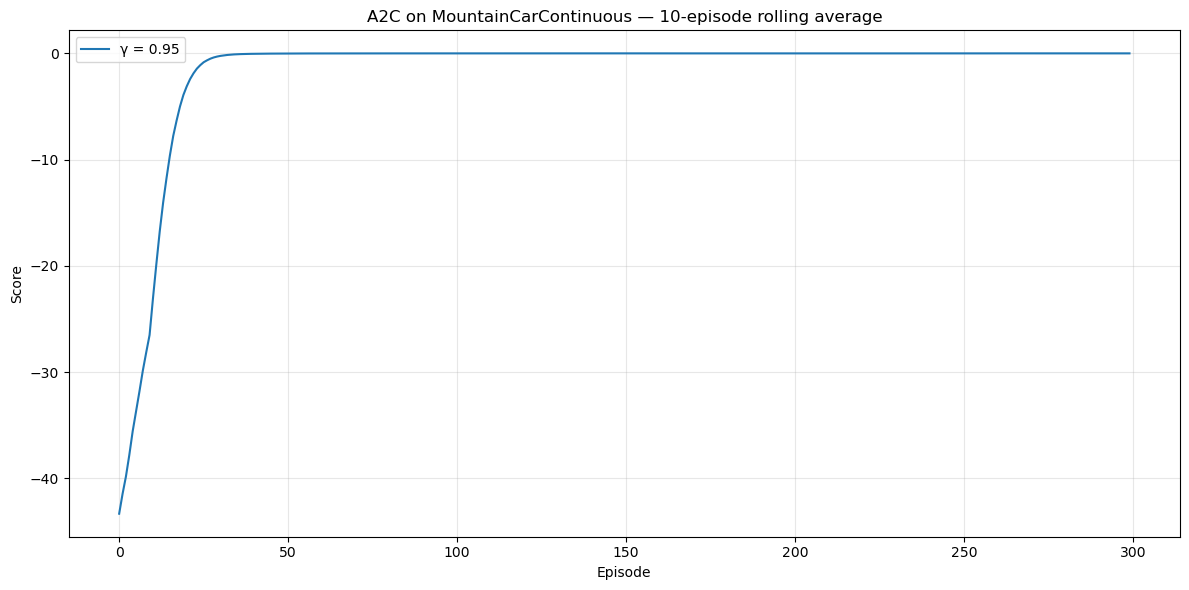

In [11]:
### Main training loop

gammas = [0.95]
num_episodes = 300
lr_actor = 0.00001
lr_critic = 0.00001
n_steps = 10 # rollout buffer update frequency

results = {}

for gamma in gammas:
    print(f'\n{"=" * 50}')
    print(f'Training with gamma = {gamma}')
    print(f'{"=" * 50}')
    results[gamma] = train_agent(
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        gamma=gamma,
        num_episodes=num_episodes,
        n_steps=n_steps,
        layer1_size=256,
        layer2_size=256,
        coeff=0.01
    )

save_results(results, filename='training_logs_gammas.pkl')
plot_all(results, window=10, filename='_a2c.png')

#### Exploration Failure and the Zero-Reward Trap

Standard on-policy A2C gets stuck at an average reward of exactly zero due to premature policy variance collapse induced by the sparse, harsh reward landscape of `MountainCarContinuous-v0`. To officially solve this environment, an agent must achieve an average reward of **+90.0 or higher over 100 consecutive trials**.

Because the car's engine is structurally too weak to climb directly to the goal, it must first drive away from the target to build momentum. Under unstructured exploration, any movement attempts initially incur small negative fuel penalties without reaching the goal. The critic network quickly determines that doing nothing (i.e., outputting a zero action) is optimal for short-term survival. Consequently, the actor progressively shrinks its exploration variance ($\sigma \rightarrow 0$), eventually eliminating exploration and becoming trapped at a flat reward of around **0.0**.

Similar behavior is also observed in Stable-Baselines3 A2C when `use_sde=False`, whereas enabling `use_sde=True` improves exploration and helps the agent to reach the goal.
To address this problem, we adopted generalized State-Dependent Exploration (gSDE), specifically the `n-step` variant, which resamples the exploration parameters every 
`n steps` and uses learned policy features to generate structured noise. This produces smoother and more temporally consistent exploration than independent Gaussian action noise, while preserving the original reward formulation. `Reward shaping` can also be used to address this problem where either `position or velocity` incentives are given to the agent.
Further details on the `gSDE` and the mathematical expressions can be found in this paper https://arxiv.org/pdf/2005.05719 


To address the zero-reward trap, we adopt **generalized State-Dependent Exploration (gSDE)**, specifically the **\(n\)-step variant**. In our implementation, the actor produces a state-dependent mean $\mu(s)$ and standard deviation $\sigma(s)$ from learned latent features, and the action is then sampled as $ a_t^{\text{raw}} = \mu(s_t) + \sigma(s_t) \odot \epsilon$, where $\epsilon \text{~} N(0, 1)$
followed by a tanh squashing function. The same exploration noise vector $\epsilon$ is reused for $n$ consecutive steps before being resampled, producing smoother and more temporally coherent exploration than independent Gaussian noise.

This structured exploration strategy helps the A2C agent maintain momentum long enough to discover successful trajectories in `MountainCarContinuous-v0`, preventing premature exploration collapse and avoiding convergence to the near-zero reward regime as shown in our simulation results.

#### Implementing the Agent Class with gSDE

In [3]:

class ActorNetwork(nn.Module):
    def __init__(self, lr, input_dims, fc1_dims, fc2_dims, n_actions):
        super().__init__()
        self.fc1 = nn.Linear(*input_dims, fc1_dims)
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.mu = nn.Linear(fc2_dims, n_actions)

        # SDE exploration weights: map state features to exploration noise scale
        self.log_std = nn.Linear(fc2_dims, n_actions)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def forward(self, state):
        if not isinstance(state, T.Tensor):
            state = T.tensor(np.array(state), dtype=T.float32)
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        mu = self.mu(x)

        log_std = self.log_std(x)
        log_std = T.clamp(log_std, -2, 2)
        std = T.exp(log_std)
        return mu, std

class CriticNetwork(nn.Module):
    def __init__(self, lr, input_dims, fc1_dims, fc2_dims):
        super().__init__()
        self.fc1 = nn.Linear(*input_dims, fc1_dims)
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.v = nn.Linear(fc2_dims, 1)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def forward(self, state):
        if not isinstance(state, T.Tensor):
            state = T.tensor(np.array(state), dtype=T.float32)
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        value = self.v(x)
        return value

class RolloutBuffer:
    def __init__(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []

    def store(self, state, action, log_prob, reward, done, value):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)

    def clear(self):
        self.states, self.actions, self.log_probs, self.rewards, self.dones, self.values = [], [], [], [], [], []



In [4]:
class Agent:
    def __init__(self, lr_actor, lr_critic, input_dims, n_actions,
                 gamma=0.99, gae_lambda=0.95, entropy_coeff=0.5,
                 layer1_size=256, layer2_size=256, min_entropy_coeff=0.2, entropy_decay=0.9995):
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.entropy_coeff = entropy_coeff
        self.n_actions = n_actions
        self.initial_entropy_coeff = entropy_coeff
        self.min_entropy_coeff = min_entropy_coeff
        self.entropy_decay = entropy_decay

        self.actor = ActorNetwork(lr_actor, input_dims, layer1_size, layer2_size, n_actions)
        self.critic = CriticNetwork(lr_critic, input_dims, layer1_size, layer2_size)
        self.memory = RolloutBuffer()

        # Persistent noise matrix for state-dependent exploration (gSDE)
        self.exploration_noise = None
        self.reset_noise()

    def reset_noise(self):
        """Samples a fresh persistent matrix for structured exploration."""
        # For simplicity in 1D action space, sample standard normal scalar/vector
        self.exploration_noise = T.randn(self.n_actions)

    def decay_entropy(self):
        self.entropy_coeff = max(
            self.min_entropy_coeff,
            self.entropy_coeff * self.entropy_decay
        )

    def choose_action(self, observation):
        state = T.tensor(np.array(observation), dtype=T.float32)

        mu, std = self.actor(state)

        # State-Dependent Exploration core logic:
        # Action noise is scaled by the variance but consistent across timesteps
        raw_action = mu + std * self.exploration_noise

        # Enforce action space bounds cleanly using Tanh
        action = T.tanh(raw_action)

        # Analytical log probability adjustment for Tanh squashing
        # log_prob(tanh(x)) = log_prob_normal(x) - log(1 - tanh(x)^2)
        dist = T.distributions.Normal(mu, std)
        raw_log_prob = dist.log_prob(raw_action).sum()
        log_prob = raw_log_prob - T.log(1.0 - action.pow(2) + 1e-8).sum()

        value = self.critic(state).squeeze()

        return action.detach().numpy(), log_prob, value

    def store_transition(self, state, action, log_prob, reward, done, value):
        self.memory.store(state, action, log_prob, reward, done, value)


    def compute_returns_advantages(self, last_state, done):
        last_state = T.tensor(np.array(last_state), dtype=T.float32)
        next_value = 0.0 if done else self.critic(last_state).item()

        rewards = self.memory.rewards
        dones = self.memory.dones
        values = [v.item() for v in self.memory.values]

        returns = []
        advantages = []

        gae = 0.0
        values = values + [next_value]

        for t in reversed(range(len(rewards))):
            delta = rewards[t] + self.gamma * values[t + 1] * (1 - int(dones[t])) - values[t]
            gae = delta + self.gamma * self.gae_lambda * (1 - int(dones[t])) * gae
            advantages.insert(0, gae)
            returns.insert(0, gae + values[t])

        returns = T.tensor(returns, dtype=T.float32)
        advantages = T.tensor(advantages, dtype=T.float32)

        advantages = (advantages - advantages.mean()) / (advantages.std(unbiased=False) + 1e-8)
        return returns, advantages

    def learn(self, last_state, done):
        returns, advantages = self.compute_returns_advantages(last_state, done)

        states = T.tensor(np.array(self.memory.states), dtype=T.float32)
        actions = T.tensor(np.array(self.memory.actions), dtype=T.float32)

        mu, std = self.actor(states)
        dist = T.distributions.Normal(mu, std)

        # Invert Tanh back safely to find raw actions for calculating updated distributions
        raw_actions = T.atanh(T.clamp(actions, -0.999, 0.999))

        # Calculate updated logs with tanh Jacobian penalty
        log_probs = dist.log_prob(raw_actions).sum(dim=-1) - T.log(1.0 - actions.pow(2) + 1e-6).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1).mean()

        critic_values = self.critic(states).squeeze(-1)

        actor_loss = -(log_probs * advantages.detach()).mean()
        critic_loss = F.mse_loss(critic_values, returns)

        # Minimize total loss
        loss = actor_loss + 0.5 * critic_loss - self.entropy_coeff * entropy

        self.actor.optimizer.zero_grad()
        self.critic.optimizer.zero_grad()
        loss.backward()

        # Gradient clipping to prevent policy explosion during momentum discoveries
        T.nn.utils.clip_grad_norm_(self.actor.parameters(), max_norm=0.5)
        T.nn.utils.clip_grad_norm_(self.critic.parameters(), max_norm=0.5)

        self.actor.optimizer.step()
        self.critic.optimizer.step()

        self.memory.clear()

### Defining Helper functions for traning and visualizatiion

In [5]:
def train_agent(lr_actor, lr_critic, gamma, num_episodes=200, n_steps=20, layer1_size=256, layer2_size=256, coeff=0.05, seed=42):
    env = gym.make('MountainCarContinuous-v0', render_mode='human')

    agent = Agent(
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        input_dims=[2],
        n_actions=1,
        gamma=gamma,
        entropy_coeff=coeff, # Notice: higher entropy coeff (e.g., 0.05) keeps distribution broad
        layer1_size=layer1_size,
        layer2_size=layer2_size
    )

    score_history = []

    T.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    for episode in range(num_episodes):
        observation, info = env.reset()
        done = False
        score = 0
        step_count = 0

        # Reset exploration direction choice at start of each trajectory run
        # agent.reset_noise()

        while not done:
            action, log_prob, value = agent.choose_action(observation)

            action = np.array(action, dtype=np.float32).reshape((1,))
            observation_, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.store_transition(
                state=observation,
                action=action,
                log_prob=log_prob,
                reward=reward,
                done=done,
                value=value
            )

            score += reward
            step_count += 1
            observation = observation_

            # Standard gSDE configuration: sample fresh noise vector every 4 steps
            if step_count % 50 == 0:
                agent.reset_noise()

            # if step_count % n_steps == 0 or done:
            agent.learn(observation, done)

        # agent.decay_entropy()
        score_history.append(score)
        print(f'gamma={gamma:.2f} | episode: {episode + 1}/{num_episodes} | score: {score:.2f} | entropy_coeff: {agent.entropy_coeff:.4f}')

    env.close()
    return score_history

def save_results(results, filename='training_logs.pkl'):
    with open(filename, 'wb') as f:
        pickle.dump(results, f)
    print(f'Training logs saved to {filename}')


def plot_all(results, window=10, filename='gamma_comparison_a2c.png'):
    plt.figure(figsize=(12, 6))

    for gamma, scores in results.items():
        scores = np.array(scores, dtype=np.float32)
        running_avg = np.zeros(len(scores))

        for t in range(len(scores)):
            running_avg[t] = np.mean(scores[max(0, t - window + 1): t + 1])

        plt.plot(running_avg, label=f'γ = {gamma}')

    plt.title(f'A2C on MountainCarContinuous — {window}-episode rolling average')
    plt.xlabel('Episode')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(filename, dpi=300)
    plt.show()


def moving_average(x, window=10):
    return np.convolve(x, np.ones(window)/window, mode='valid')

In [ ]:
### Main training loop with different gamma values

gammas = [0.99, 0.95, 0.90, 0.80]#, 0.70, 0.50, 0.30, 0.10]
num_episodes = 300
lr_actor = 0.0001
lr_critic = 0.0001
n_steps = 10

results = {}

for gamma in gammas:
    print(f'\n{"=" * 50}')
    print(f'Training with gamma = {gamma}')
    print(f'{"=" * 50}')
    results[gamma] = train_agent(
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        gamma=gamma,
        num_episodes=num_episodes,
        n_steps=n_steps,
        layer1_size=256,
        layer2_size=256,
        coeff=0.01
    )

save_results(results, filename='training_logs_gammas.pkl')
plot_all(results, window=10, filename='gamma_comparison_a2c.png')


Training with gamma = 0.99


/home/einsbert/anaconda3/envs/torch_drl/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


gamma=0.99 | episode: 1/300 | score: 70.83 | entropy_coeff: 0.0100
gamma=0.99 | episode: 2/300 | score: 87.14 | entropy_coeff: 0.0100
gamma=0.99 | episode: 3/300 | score: 61.42 | entropy_coeff: 0.0100
gamma=0.99 | episode: 4/300 | score: 70.10 | entropy_coeff: 0.0100
gamma=0.99 | episode: 5/300 | score: 81.85 | entropy_coeff: 0.0100
gamma=0.99 | episode: 6/300 | score: 86.55 | entropy_coeff: 0.0100
gamma=0.99 | episode: 7/300 | score: 82.99 | entropy_coeff: 0.0100
gamma=0.99 | episode: 8/300 | score: 90.48 | entropy_coeff: 0.0100
gamma=0.99 | episode: 9/300 | score: 89.76 | entropy_coeff: 0.0100
gamma=0.99 | episode: 10/300 | score: 68.16 | entropy_coeff: 0.0100
gamma=0.99 | episode: 11/300 | score: 81.08 | entropy_coeff: 0.0100
gamma=0.99 | episode: 12/300 | score: 51.74 | entropy_coeff: 0.0100
gamma=0.99 | episode: 13/300 | score: 80.00 | entropy_coeff: 0.0100
gamma=0.99 | episode: 14/300 | score: 80.40 | entropy_coeff: 0.0100
gamma=0.99 | episode: 15/300 | score: 88.24 | entropy_coe

> The results demonstrate the significant impact of the discount factor on training stability and convergence behavior in A2C. Lower discount factors converge rapidly due to reduced variance in temporal-difference targets, but may emphasize short-term rewards. Higher discount factors encourage long-term planning but introduce instability due to error accumulation in bootstrapped value estimates. In particular, `γ=0.99` exhibits severe late-stage instability and policy collapse, indicating that excessively large discount factors can negatively affect critic stability in actor-critic methods. Intermediate values such as `γ=0.7` and `γ=0.8` provide the best balance between stability and long-term reward optimization with `γ=0.95` finishing on top with the best performance.
- As such `γ=0.95` is used in the subsequent training 

> Because MountainCarContinuous has sparse/delayed rewards, theoretically larger γ should help.
But in practice:

- function approximation,
- bootstrapping,
- and stochastic gradient updates
make very high γ difficult to train stably.

#### LEANRING RATE ANALYSIS OF A2C On MOUNTAINCAR-CONTINUOUS    


In [ ]:
### Training loop with different combinations of actor and critic learning rates

def plot_all_lr(results, window=10, filename='lr_comparison_a2c.png'):
    """
    results: dict of {(lr_actor, lr_critic): score_history_list}
    """
    plt.figure(figsize=(10, 6))

    for (lr_actor, lr_critic), scores in results.items():
        scores = np.array(scores, dtype=np.float32)
        running_avg = np.zeros(len(scores))

        for t in range(len(scores)):
            running_avg[t] = np.mean(scores[max(0, t - window + 1): t + 1])

        label = f"actor={lr_actor:.0e}, critic={lr_critic:.0e}"
        plt.plot(running_avg, label=label)

    plt.title(f'A2C on MountainCarContinuous ({window}-episode rolling average)')
    plt.xlabel('Episode')
    plt.ylabel('Score')
    plt.legend(loc='best', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(filename, dpi=600)
    print(f'Plot saved to {filename}')

In [ ]:
gamma = 0.95
num_episodes = 100
n_steps = 50

lr_combinations = [
    (0.00001,  0.000005),
    (0.00005,  0.0001),
    (0.0001,   0.00005),
    (0.00001,  0.00001),
    (0.0001,   0.0001),
    (0.001, 0.001),
]

results = {}

for lr_actor, lr_critic in lr_combinations:
    label = f"actor={lr_actor:.0e}, critic={lr_critic:.0e}"
    print(f'\n{"=" * 50}')
    print(f'Training with {label}')
    print(f'{"=" * 50}')

    results[(lr_actor, lr_critic)] = train_agent(
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        gamma=gamma,
        num_episodes=num_episodes,
        n_steps=n_steps,
        layer1_size=256,
        layer2_size=256,
        coeff=0.01
    )

# save_results(results, filename='training_logs_lr.pkl')
# plot_all_lr(results, window=10, filename='lr_comparison_a2c.png')


Training with actor=1e-05, critic=5e-06
gamma=0.95 | episode: 1/100 | score: 78.93 | entropy_coeff: 0.0100
gamma=0.95 | episode: 2/100 | score: 39.88 | entropy_coeff: 0.0100
gamma=0.95 | episode: 3/100 | score: 82.11 | entropy_coeff: 0.0100
gamma=0.95 | episode: 4/100 | score: 74.56 | entropy_coeff: 0.0100
gamma=0.95 | episode: 5/100 | score: 73.60 | entropy_coeff: 0.0100
gamma=0.95 | episode: 6/100 | score: 83.54 | entropy_coeff: 0.0100
gamma=0.95 | episode: 7/100 | score: 16.64 | entropy_coeff: 0.0100
gamma=0.95 | episode: 8/100 | score: 80.51 | entropy_coeff: 0.0100
gamma=0.95 | episode: 9/100 | score: 87.59 | entropy_coeff: 0.0100
gamma=0.95 | episode: 10/100 | score: 87.10 | entropy_coeff: 0.0100
gamma=0.95 | episode: 11/100 | score: 42.98 | entropy_coeff: 0.0100
gamma=0.95 | episode: 12/100 | score: 65.08 | entropy_coeff: 0.0100
gamma=0.95 | episode: 13/100 | score: 92.17 | entropy_coeff: 0.0100
gamma=0.95 | episode: 14/100 | score: 72.80 | entropy_coeff: 0.0100
gamma=0.95 | epi

Training logs saved to training_logs_lr.pkl
Plot saved to lr_comparison_a2c.png


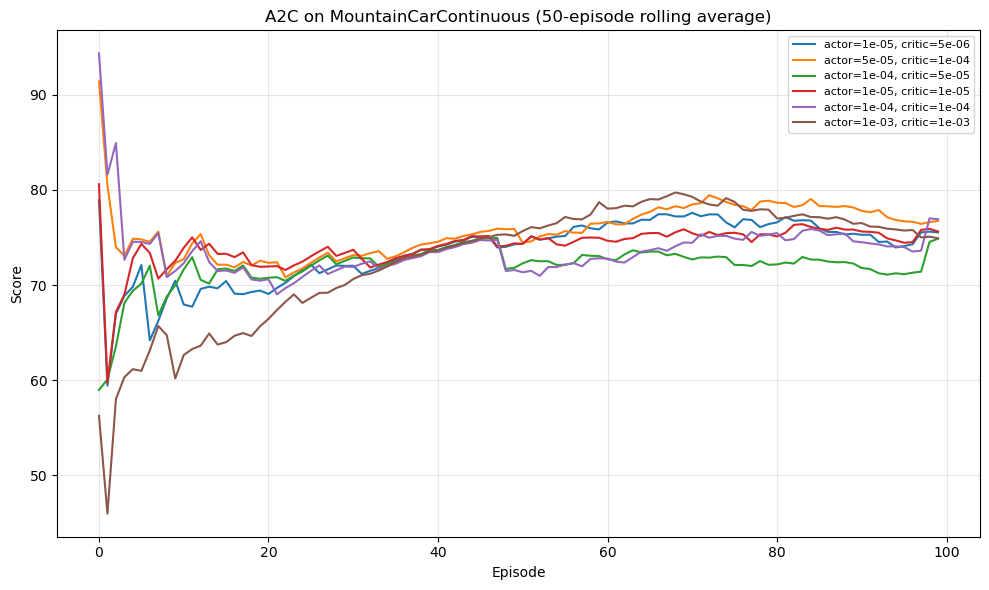

In [ ]:
save_results(results, filename='training_logs_lr.pkl')
plot_all_lr(results, window=50, filename='lr_comparison_a2c.png')

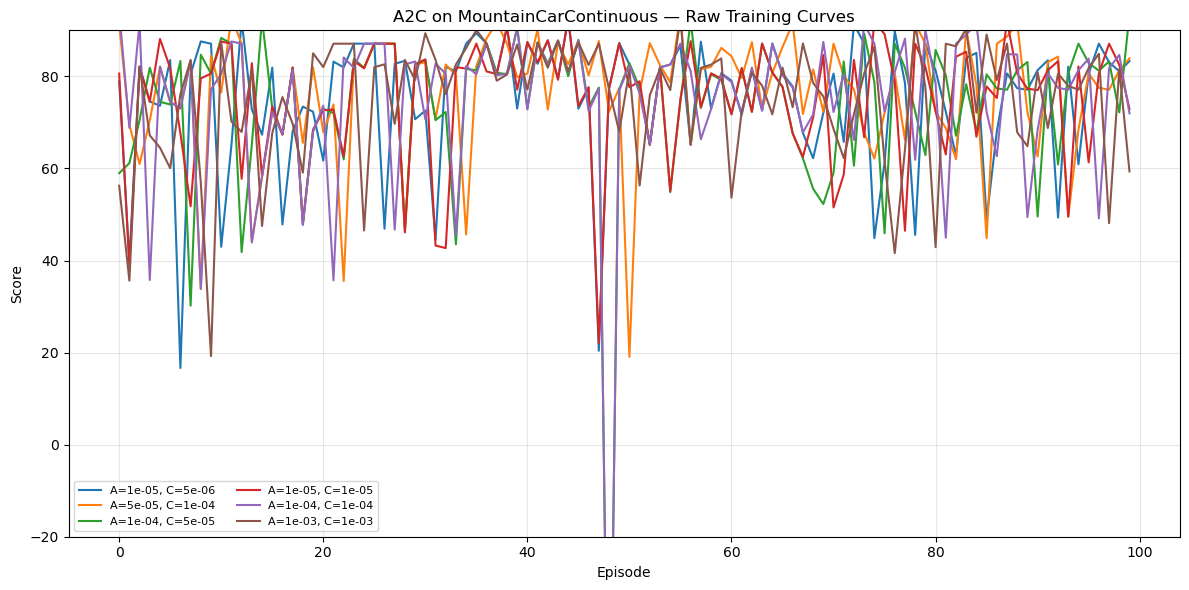

In [ ]:
# =========================================================
# Load training logs
# =========================================================
with open("training_logs_lr.pkl", "rb") as f:
    logs = pickle.load(f)

# =========================================================
# 1. RAW CURVES WITH Y-LIMIT [-5, 0]
# =========================================================
fig, ax = plt.subplots(figsize=(12,6))

for (lr_actor, lr_critic), rewards in logs.items():

    rewards = np.array(rewards)

    label = f"A={lr_actor:.0e}, C={lr_critic:.0e}"

    ax.plot(rewards, linewidth=1.5, label=label)

ax.set_title("A2C on MountainCarContinuous — Raw Training Curves")
ax.set_xlabel("Episode")
ax.set_ylabel("Score")

# Reduced y-axis
ax.set_ylim(-20, 90)

ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

**General observations**
- Symmetric learning rates (actor and critic at the same scale) tend to produce more stable training than asymmetric combinations. 
- Configurations where either the actor or critic LR is much larger than the other show higher variance and slower convergence.


- As a result, we stick with `A=5e-05, C=1e-04`. It offers the best combination of stable convergence, low variance in the late training phase, and consistently high final score.

#### VArrying the entropy coefficient and look at it impact on the A2C training

In [ ]:
def plot_all_coef(results, window=10, filename='coeff_comparison_a2c.png'):
    """
    results: dict of {entropy_coeff: score_history_list}
    """
    plt.figure(figsize=(14, 8))

    for coeff, scores in results.items():
        scores = np.array(scores, dtype=np.float32)
        running_avg = np.zeros(len(scores))

        for t in range(len(scores)):
            running_avg[t] = np.mean(scores[max(0, t - window + 1): t + 1])

        label = f"coeff={coeff:.0e}"
        plt.plot(running_avg, label=label)

    plt.title(f'A2C on MountainCarContinuous ({window}-episode rolling average)')
    plt.xlabel('Episode')
    plt.ylabel('Score')
    plt.legend(loc='best', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(filename, dpi=300)
    print(f'Plot saved to {filename}')


gamma = 0.95
num_episodes = 1000
n_steps = 50

# Fixed learning rates for this experiment
lr_actor = 0.00005
lr_critic = 0.0001

# Entropy coefficient combinations to test
coeff_combinations = [
    0.0,     # no entropy regularization
    0.01,   # very low entropy
    0.05,   # low entropy
    0.1,
    0.5,
]

results = {}

for coeff in coeff_combinations:
    label = f"coeff={coeff:.0e}"
    print(f'\n{"=" * 50}')
    print(f'Training with {label}')
    print(f'{"=" * 50}')

    results[coeff] = train_agent(
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        gamma=gamma,
        num_episodes=num_episodes,
        n_steps=n_steps,
        layer1_size=256,
        layer2_size=256,
        coeff=coeff,
    )

save_results(results, filename='training_logs_coeff.pkl')
plot_all_coef(results, window=20, filename='coeff_comparison_a2c.png')

<!-- > From the training, 
- Higher entropy coefficients corresponds to early convergence of A2C to a local optimum performance.
- Lower entropy coefficients corresponds to the A2C not converging faster and encouraging exploration which could lead to global optimum performance -->